RAPIDS cuML-Assignment6

Q1. Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and
implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated
binning and model training.

In [ ]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.11.13 environment at: /usr
Audited 9 packages in 203ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to update your personal files.
            - If an installation failure persists when using the latest script, please make an issue on https://github.com/rapidsai-community/rapidsai-csp-utils
        ***********************************************************************
        


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [ ]:
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame

continuous_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
binary_cols = ['sex']

print("continuous:", continuous_cols)
print("categorical:", categorical_cols)
print("gpu eligible (continuous):", continuous_cols)

continuous: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
gpu eligible (continuous): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


GPU time: 0.00186s
CPU time: 0.00104s


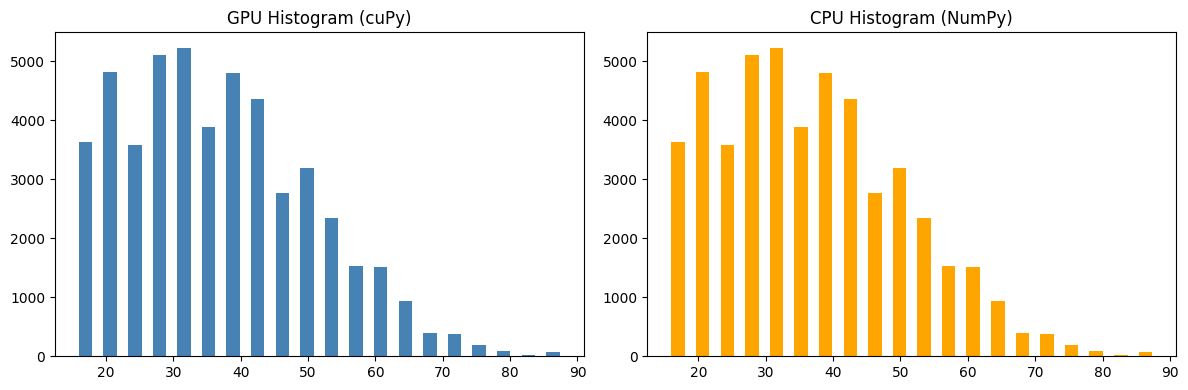

In [ ]:
col = 'age'
gpu_arr = cp.array(df[col].dropna().values)
cpu_arr = df[col].dropna().values

t0 = time.time()
gpu_hist, gpu_edges = cp.histogram(gpu_arr, bins=20)
t1 = time.time()
cpu_hist, cpu_edges = np.histogram(cpu_arr, bins=20)
t2 = time.time()

print(f"GPU time: {t1-t0:.5f}s")
print(f"CPU time: {t2-t1:.5f}s")

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(cp.asnumpy(gpu_edges[:-1]), cp.asnumpy(gpu_hist), width=2, color='steelblue')
axes[0].set_title('GPU Histogram (cuPy)')
axes[1].bar(cpu_edges[:-1], cpu_hist, width=2, color='orange')
axes[1].set_title('CPU Histogram (NumPy)')
plt.tight_layout()
plt.show()

In [ ]:
gdf = cudf.DataFrame(df[continuous_cols].fillna(0))

n_bins = 5
for c in continuous_cols:
    quantiles = gdf[c].quantile([i/n_bins for i in range(n_bins+1)])
    gdf[c + '_bin'] = pd.cut(gdf[c].to_pandas(),
                             bins=quantiles.to_pandas(),
                             labels=False, duplicates='drop')

print(gdf[['age', 'age_bin']].head(10).to_pandas())

   age  age_bin
0   25      0.0
1   38      2.0
2   28      1.0
3   44      3.0
4   18      0.0
5   34      2.0
6   29      1.0
7   63      4.0
8   24      0.0
9   55      4.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df2 = df.copy()
for col in df2.select_dtypes('category').columns:
    df2[col] = df2[col].astype(str)
df2 = df2.fillna('missing')

for col in df2.select_dtypes('object').columns:
    df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

X = df2.drop('class', axis=1).values
y = (df2['class'] == 1).astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

t0 = time.time()
xgb = XGBClassifier(device='cuda', eval_metric='logloss')
xgb.fit(X_train, y_train)
print(f"XGBoost gpu_hist acc: {xgb.score(X_test, y_test):.4f}  time: {time.time()-t0:.2f}s")

X_cu = cudf.DataFrame(X_train.astype(np.float32))
y_cu = cudf.Series(y_train.astype(np.int32))
t0 = time.time()
clf = cuRF(n_estimators=100)
clf.fit(X_cu, y_cu)
preds = clf.predict(cudf.DataFrame(X_test.astype(np.float32)))
acc = (cp.array(preds.to_pandas().values) == cp.array(y_test)).mean()
print(f"cuML RF acc: {float(acc):.4f}  time: {time.time()-t0:.2f}s")

XGBoost gpu_hist acc: 0.8778  time: 0.37s
cuML RF acc: 0.8688  time: 0.49s


Q2. Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML
(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different
levels of GPU parallelism

In [ ]:

import cudf
import cupy as cp
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from cuml.ensemble import RandomForestClassifier as cuRF

In [ ]:
data = load_breast_cancer()
X, y = data.data.astype(np.float32), data.target.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_train_cu = cudf.DataFrame(X_train)
X_test_cu  = cudf.DataFrame(X_test)
y_train_cu = cudf.Series(y_train)
y_test_cu  = cudf.Series(y_test)

print(f"train: {X_train.shape}  test: {X_test.shape}")

train: (455, 30)  test: (114, 30)


In [ ]:
t0 = time.time()
cpu_clf = RandomForestClassifier(n_estimators=100, random_state=0)
cpu_clf.fit(X_train, y_train)
cpu_train_time = time.time() - t0

t0 = time.time()
cpu_preds = cpu_clf.predict(X_test)
cpu_pred_time = time.time() - t0

cpu_acc = accuracy_score(y_test, cpu_preds)
print(f"CPU  train={cpu_train_time:.3f}s  pred={cpu_pred_time:.4f}s  acc={cpu_acc:.4f}")

CPU  train=0.222s  pred=0.0091s  acc=0.9649


In [ ]:
t0 = time.time()
gpu_clf = cuRF(n_estimators=100, random_state=0)
gpu_clf.fit(X_train_cu, y_train_cu)
gpu_train_time = time.time() - t0

t0 = time.time()
gpu_preds = gpu_clf.predict(X_test_cu).to_numpy()
gpu_pred_time = time.time() - t0

gpu_acc = accuracy_score(y_test, gpu_preds)
speedup = cpu_train_time / gpu_train_time
print(f"GPU  train={gpu_train_time:.3f}s  pred={gpu_pred_time:.4f}s  acc={gpu_acc:.4f}")
print(f"speedup: {speedup:.2f}x")

GPU  train=0.165s  pred=0.0043s  acc=0.9561
speedup: 1.35x


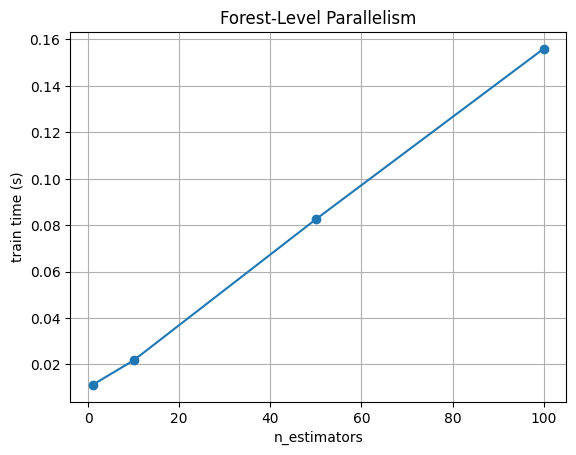

In [ ]:
n_vals = [1, 10, 50, 100]
times = []

for n in n_vals:
    t0 = time.time()
    cuRF(n_estimators=n).fit(X_train_cu, y_train_cu)
    times.append(time.time() - t0)

plt.plot(n_vals, times, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('train time (s)')
plt.title('Forest-Level Parallelism')
plt.grid(True)
plt.show()

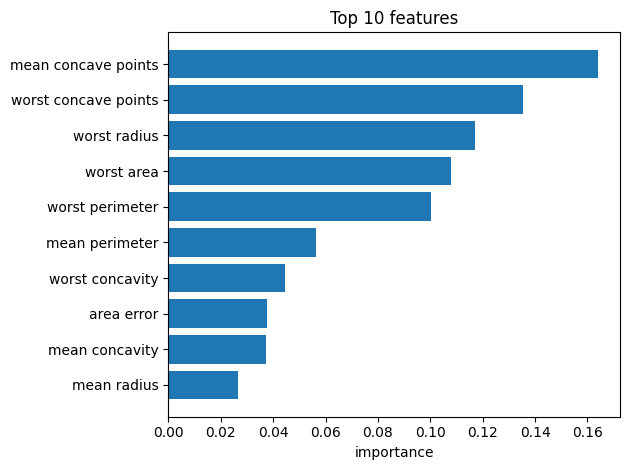

In [ ]:
importances = gpu_clf.feature_importances_
feat_names = data.feature_names

idx = np.argsort(importances)[::-1][:10]
plt.barh(feat_names[idx][::-1], importances[idx][::-1])
plt.xlabel('importance')
plt.title('Top 10 features')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


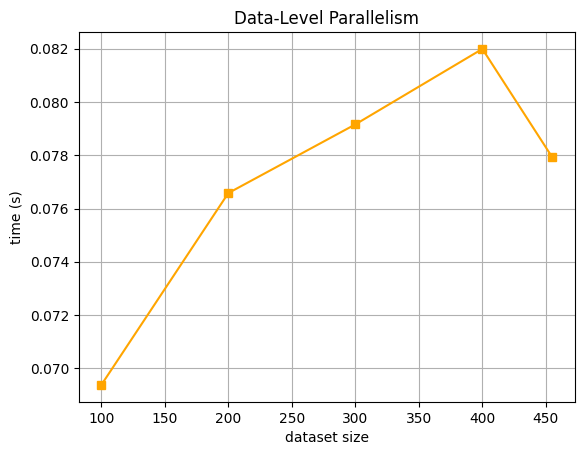

In [ ]:
sizes = [100, 200, 300, 400, len(X_train)]
dtimes = []

for s in sizes:
    Xs = cudf.DataFrame(X_train[:s])
    ys = cudf.Series(y_train[:s])
    t0 = time.time()
    cuRF(n_estimators=50).fit(Xs, ys)
    dtimes.append(time.time() - t0)

plt.plot(sizes, dtimes, marker='s', color='orange')
plt.xlabel('dataset size')
plt.ylabel('time (s)')
plt.title('Data-Level Parallelism')
plt.grid(True)
plt.show()

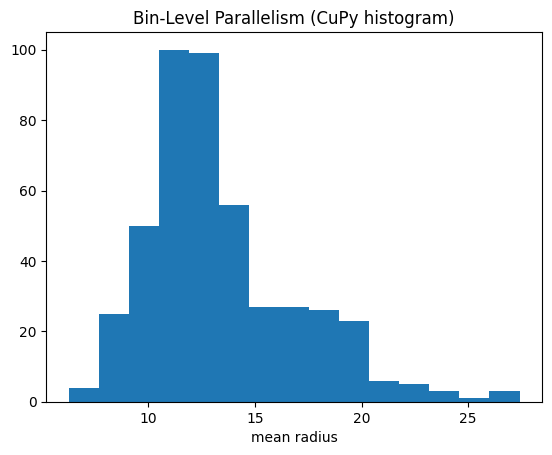

In [ ]:
col_gpu = cp.array(X_train[:, 0])
hist, edges = cp.histogram(col_gpu, bins=15)

plt.bar(cp.asnumpy(edges[:-1]), cp.asnumpy(hist), width=(edges[1]-edges[0]).item())
plt.title('Bin-Level Parallelism (CuPy histogram)')
plt.xlabel(data.feature_names[0])
plt.show()

     method  train_time  pred_time  accuracy
CPU sklearn    0.222376   0.009147  0.964912
   GPU cuML    0.165097   0.004251  0.956140


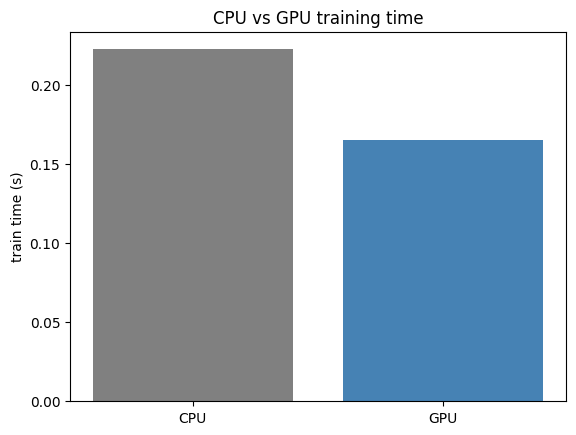

In [ ]:
results = pd.DataFrame({
    'method': ['CPU sklearn', 'GPU cuML'],
    'train_time': [cpu_train_time, gpu_train_time],
    'pred_time':  [cpu_pred_time,  gpu_pred_time],
    'accuracy':   [cpu_acc,        gpu_acc]
})
print(results.to_string(index=False))

fig, ax = plt.subplots()
ax.bar(['CPU', 'GPU'], [cpu_train_time, gpu_train_time], color=['gray', 'steelblue'])
ax.set_ylabel('train time (s)')
ax.set_title('CPU vs GPU training time')
plt.show()